# ER r=0 Simulation vs Theory

This notebook keeps the reset concepts explicit in the source code, but the plot itself is only for `r = 0`.

The plot contains 8 lines total:
- 4 simulation traces for different expected degrees $\mu$ on ER graphs,
- 4 horizontal theory lines for the corresponding $r=0$ predictions.

The reset distribution and the placement protocol are defined separately in the code to reflect the distinction we discussed, even though they do not affect the `r = 0` trajectories.

In [ ]:
using Graphs
using Random
using Statistics
using Printf
using Plots

project_root = isdir(joinpath(pwd(), "src")) ? pwd() : dirname(dirname(pwd()))

# Always reload local module so new API changes are available in this kernel.
include(joinpath(project_root, "src", "VoterResetting.jl"))

# Keep the distinction explicit: a reset distribution is not the same as a placement protocol.
reset_distribution = VoterResetting.delta_reset(0.0)
placement_protocol = VoterResetting.hub_reset(0.0; highest=true)

# The r=0 plot below does not use reset events, but the names stay separate in the code.
mu_values = [4, 6, 10, 30]
N = 1000
m0 = 0.0
n_realizations = 20
total_iterations = 400_000
sample_every = 1000
seed = 1234
den_tol = 1e-12

println("Reset distribution: delta_reset(0.0)")
println("Placement protocol: hub_reset(0.0; highest=true)")
println("These are distinct knobs; for r = 0 they are inactive but kept explicit.")

ER ready: N=1000, target_mu=8, realized_mean_degree=8.26, min_degree=0, n_realizations=50
The graph/cache here are only used for the reset-state reference line.


delta reset reset reference: rho0=0.49855, sigma0=0.50000, normalized=1.99419
WARNING [high-hub reset]: tail mean for mu=30 is outside [baseline, r=∞] band: 1.93538 not in [1.33979, 1.88281]
high-hub reset reset reference: rho0=0.47070, sigma0=0.50000, normalized=1.88281


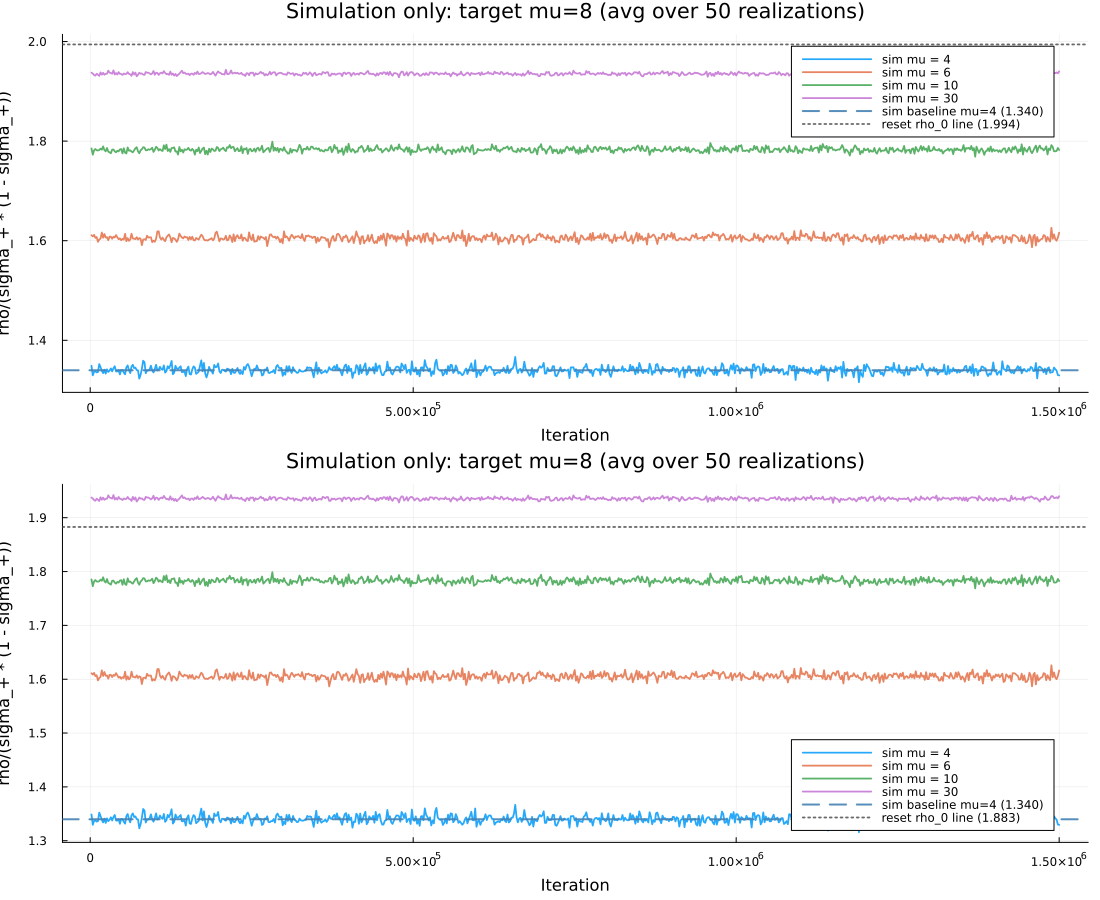

In [ ]:
function qs_trace_r0_er(mu::Int, N::Int, m0::Float64, total_iters::Int, sample_every::Int; seed::Int=1234)
    Random.seed!(seed + 100 * mu)
    p_edge = mu / (N - 1)
    G_mu = erdos_renyi(N, p_edge)
    cache = VoterResetting.build_graph_cache(G_mu)

    state = VoterResetting.random_spin_state(N, m0)
    active_list = VoterResetting.active_edge_ids_from_state(cache, state)
    pos_map = zeros(Int, ne(G_mu))
    VoterResetting.rebuild_active_structures!(active_list, pos_map, copy(active_list))

    ns = Int(floor(total_iters / sample_every)) + 1
    trace = fill(NaN, ns)

    function normalized_rho(st, active_count::Int)
        sigma_plus = count(==(Int8(1)), st) / length(st)
        den = sigma_plus * (1.0 - sigma_plus)
        if den <= den_tol
            return NaN
        end
        rho_inst = active_count / ne(G_mu)
        return rho_inst / den
    end

    trace[1] = normalized_rho(state, length(active_list))
    sample_idx = 2

    for step in 1:total_iters
        if isempty(active_list)
            # Quasi-stationary continuation: restart from m0 when absorbed.
            state = VoterResetting.random_spin_state(N, m0)
            active_list = VoterResetting.active_edge_ids_from_state(cache, state)
            VoterResetting.rebuild_active_structures!(active_list, pos_map, copy(active_list))
        end

        e_id = active_list[rand(1:length(active_list))]
        u = cache.edge_u[e_id]
        v = cache.edge_v[e_id]
        flipped_node = rand(Bool) ? u : v
        state[flipped_node] *= Int8(-1)
        VoterResetting.update_incident_edges!(active_list, pos_map, cache, state, flipped_node)

        if step % sample_every == 0
            trace[sample_idx] = normalized_rho(state, length(active_list))
            sample_idx += 1
        end
    end

    return trace
end

theory_r0(mu::Int) = 2.0 * (mu - 2) / (mu - 1)

sim_traces = Dict{Int, Vector{Float64}}()
for mu in mu_values
    trace_mat = Matrix{Float64}(undef, Int(floor(total_iterations / sample_every)) + 1, n_realizations)
    for rep in 1:n_realizations
        trace_mat[:, rep] = qs_trace_r0_er(mu, N, m0, total_iterations, sample_every; seed=seed + 10_000 * rep)
    end
    sim_traces[mu] = [mean(filter(!isnan, trace_mat[t, :])) for t in 1:size(trace_mat, 1)]
end

plot_start_idx = 2
plot_axis = collect(0:sample_every:total_iterations)[plot_start_idx:end]
colors = palette(:tab10)
p = plot(
    size=(1000, 650),
    xlabel="Iteration",
    ylabel="rho/(sigma_+ * (1 - sigma_+))",
    title="ER r = 0: simulation traces and theory predictions",
    legend=:topright,
    grid=true,
    margin=6Plots.mm,
 )

for (idx, mu) in enumerate(mu_values)
    color = colors[idx]
    y_sim = sim_traces[mu][plot_start_idx:end]
    plot!(p, plot_axis, y_sim; color=color, lw=2.0, alpha=0.9, label="sim μ=$(mu)")
    hline!(p, [theory_r0(mu)]; color=color, lw=1.8, ls=:dash, alpha=0.95, label="theory μ=$(mu)")
end

display(p)